In [1]:
!bash -lc 'module load Miniforge3/24.1.2-0 && source $EBROOTMINIFORGE3/bin/activate && conda activate hycom-cice'
import geopandas as gpd
import matplotlib.pyplot as plt
import xhycom
import regionmask
import numpy as np
import xarray as xr

The following modules were not unloaded:
  (Use "module --force purge" to unload all):

  1) StdEnv


In [2]:
INPUT = "IPCC_regions_ocean_propostion_20260607.shp"
TARGET = "/cluster/home/arnelt/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
OUTPUT = "AR7_regions_TOPAZ2.nc"

gdf = gpd.read_file(INPUT)

ds = xhycom.open_dataset(TARGET)
ds = ds[["plat", "plon"]].rename({"plat":"lat", "plon":"lon"})

<Axes: xlabel='x', ylabel='y'>

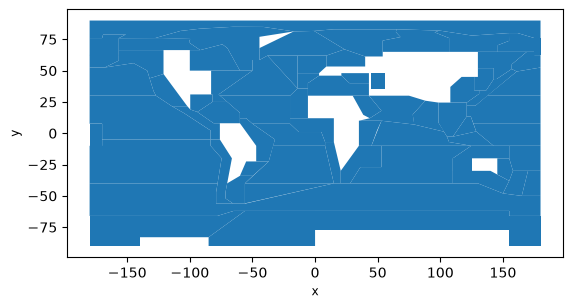

In [3]:
# Check input regions
gdf.plot()

In [4]:
# Map regions to target grid and handle dupplicate names and dateline

# Make sure polygons and dataset coordinates use the same CRS
gdf = gdf.set_crs("EPSG:4326")

# Preserve the original region name
gdf["region_name"] = gdf["Name"]

# Create one integer ID per unique region name
region_names = gdf["region_name"].drop_duplicates().tolist()

name_to_id = {
    name: region_id
    for region_id, name in enumerate(region_names)
}

# Unique ID for EVERY polygon -- required by regionmask
gdf["polygon_id"] = np.arange(len(gdf))

region_def = regionmask.from_geopandas(
    gdf,
    numbers="polygon_id",
    overlap=False,
)

# Create 2D mask using the unique polygon IDs
polygon_mask = region_def.mask(
    ds.lon,
    ds.lat,
)

# Map polygon IDs -> merged region IDs
polygon_to_region = gdf.set_index("polygon_id")["region_name"].map(name_to_id)

# Start with NaN everywhere
region_mask = xr.full_like(
    polygon_mask,
    np.nan,
    dtype=float,
)

# Replace each polygon ID with its merged region ID
for polygon_id, region_id in polygon_to_region.items():
    region_mask = region_mask.where(
        polygon_mask != polygon_id,
        float(region_id),
    )

# Store the merged numeric region IDs
ds["region"] = region_mask

# Inverse dictionary: integer ID -> region name
id_to_name = {v: k for k, v in name_to_id.items()}

In [5]:
# ID to name mapping
id_to_name

{0: 'Agulhas-Current',
 1: 'Canary-Current',
 2: 'Somali-Coastal-Current',
 3: 'Guinea-Current',
 4: 'Benguela-Current',
 5: 'Red-Sea',
 6: 'Arabian-Sea',
 7: 'Bay-of-Bengal',
 8: 'Sulu-Celebes-Seas',
 9: 'Indonesian-Sea',
 10: 'Kuroshio-Oyashio-Currents',
 11: 'Okhotsk.Sea',
 12: 'South-China-Sea&Gulf-of-Thailand',
 13: 'Sea-of-Japan',
 14: 'Yellow&East-China-Seas',
 15: 'Baltic-Sea',
 16: 'Black-Sea',
 17: 'Caspian-Sea',
 18: 'European.North-West-Shelf',
 19: 'Ibiria.Bay-of-Biscay',
 20: 'Mediterranean-Sea',
 21: 'E.North-America',
 22: 'Gulf-of-Alaska',
 23: 'Hudson-Bay-Complex',
 24: 'California-Current-Gulf',
 25: 'Pacific.Central-America',
 26: 'Caribbean-Sea',
 27: 'Gulf.of.Mexico',
 28: 'N.E.Brazil-Shelf',
 29: 'S.Brazil-Shelf',
 30: 'Patagonian-Shelf',
 31: 'Humboldt-Current',
 32: 'W.Australian-Shelf',
 33: 'E.Australian-Shelf',
 34: 'N.Australian-Shelf',
 35: 'S.Australian-Shelf',
 36: 'Tasman-Sea',
 37: 'New-Zealand-Shelf',
 38: 'Admundsen&Bellingshausen-Seas',
 39: 'Ross-S

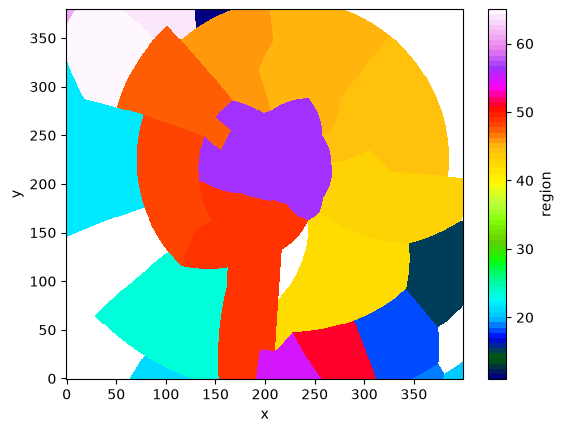

In [6]:
# Check output regions
cmap = plt.colormaps["gist_ncar"].resampled(72)

ds["region"].plot(cmap=cmap)

In [7]:
# Save output
ds.to_netcdf(OUTPUT)